# Phase 2 — Laiba's Complete Integration (D1, D2, D3 + Roma's Real C1/C2/C3 + Phase 1's Real Model)

This is the full sync-point notebook: your agent loop + Chain-of-Thought +
sufficiency/fallback wiring, running against Roma's REAL saved outputs and
Phase 1's REAL fine-tuned model — not fake test data.

**Before running:** Runtime → Change runtime type → GPU (T4) → Save.


## 1. Confirm GPU is active

In [ ]:
import torch
print("CUDA available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only")


CUDA available: True
Device: Tesla T4


## 2. Upload your D1-D3 code

In [ ]:
from google.colab import files

print("Select Laiba_Phase2_D1_D2_D3_Code.zip")
uploaded = files.upload()


Select Laiba_Phase2_D1_D2_D3_Code.zip


Saving Laiba_Phase2_D1_D2_D3_Code.zip to Laiba_Phase2_D1_D2_D3_Code.zip


In [ ]:
!unzip -o -q Laiba_Phase2_D1_D2_D3_Code.zip -d Phase2_Laiba
%cd Phase2_Laiba
!find . -type f


/content/Phase2_Laiba/Phase2_Laiba/Phase2_Laiba
./src/d1_agent_loop.py
./src/d3_sufficiency_and_fallback.py
./src/d2_cot_prompting.py
./README.md


## 3. Install dependencies

In [ ]:
!pip install -q sentence-transformers hnswlib pandas rapidfuzz


## 4. Mount Drive and pull in everything you need

This pulls from TWO places already saved in your Drive:
- Phase 1's real model + index (`MemberB_B4_B6_output`)
- Roma's real C1/C2/C3 outputs (`Phase2_Project/Roma_output`)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

PHASE1_DIR = "/content/drive/MyDrive/Phase1_Project/MemberB_B4_B6_output"
ROMA_DIR = "/content/drive/MyDrive/Phase2_Project/Roma_output"

print("Phase 1 outputs:")
!ls "{PHASE1_DIR}"
print("\nRoma's Phase 2 outputs:")
!ls "{ROMA_DIR}"


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Phase 1 outputs:
b5_real_finetuned  data  index	outputs

Roma's Phase 2 outputs:
data  quranNLP	src


## 5. Copy everything into this session

In [ ]:
import shutil, os

# Phase 1's real model + index
shutil.copytree(f"{PHASE1_DIR}/b5_real_finetuned", "b5_real_finetuned", dirs_exist_ok=True)
shutil.copytree(f"{PHASE1_DIR}/index", "index", dirs_exist_ok=True)

# Roma's real C1/C2/C3 outputs and scripts
shutil.copytree(f"{ROMA_DIR}/quranNLP", "quranNLP", dirs_exist_ok=True)
shutil.copytree(f"{ROMA_DIR}/data", "data", dirs_exist_ok=True)
for fname in ["c1_cross_lingual_fallback.py", "c2_sufficiency_labels.py",
              "c3_query_refinement.py", "b6_build_index_and_retrieval_api.py"]:
    src_path = f"{ROMA_DIR}/src/{fname}"
    if os.path.exists(src_path):
        shutil.copy(src_path, f"src/{fname}")
        print(f"Copied {fname}")
    else:
        print(f"[MISSING] {fname} not found in Roma_output/src - upload it manually if needed.")

print("\nReady.")


Copied c1_cross_lingual_fallback.py
Copied c2_sufficiency_labels.py
Copied c3_query_refinement.py
Copied b6_build_index_and_retrieval_api.py

Ready.





## 6. Load Phase 1's real retrieval API

In [ ]:
import sys
sys.path.insert(0, "src")

from sentence_transformers import SentenceTransformer
from b6_build_index_and_retrieval_api import load_index, RetrievalAPI

model = SentenceTransformer("./b5_real_finetuned")
index, entries = load_index(dim=model.get_sentence_embedding_dimension(), out_dir="index")
retrieval_api = RetrievalAPI(model, index, entries)
print(f"Loaded real retrieval API with {len(entries)} indexed entries.")


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loaded real retrieval API with 12472 indexed entries.


/tmp/ipykernel_4057/385116543.py:8: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  index, entries = load_index(dim=model.get_sentence_embedding_dimension(), out_dir="index")


## 7. Wire in Roma's real C1 (cross-lingual fallback)

In [ ]:
import json
from c1_cross_lingual_fallback import CrossLingualLookup
from d3_sufficiency_and_fallback import CrossLingualFallback

with open("quranNLP/shared/data/ayatec_records.json", encoding="utf-8") as f:
    ayatec_records = json.load(f)
with open("quranNLP/shared/data/squad_v2_sample.json", encoding="utf-8") as f:
    squad_records = json.load(f)

print(f"Loaded {len(ayatec_records)} real AyaTEC records, {len(squad_records)} SQuAD v2 records.")

lookup = CrossLingualLookup(ayatec_records, squad_records)
fallback = CrossLingualFallback(lookup_fn=lookup)


Loaded 207 real AyaTEC records, 500 SQuAD v2 records.


In [ ]:
import json
with open("quranNLP/shared/data/ayatec_records.json", encoding="utf-8") as f:
    data = json.load(f)
print(f"Records: {len(data)}")

Records: 207


## 8. Wire in Roma's real C2 (calibrated sufficiency threshold)

In [ ]:
from d3_sufficiency_and_fallback import SufficiencyScorer

with open("data/sufficiency_labels.json", encoding="utf-8") as f:
    labeled_examples = json.load(f)

print(f"Loaded {len(labeled_examples)} real sufficiency-labeled examples.")

scorer = SufficiencyScorer()
scorer.calibrate(labeled_examples)


Loaded 200 real sufficiency-labeled examples.
[OK] Calibrated sufficiency threshold: 0.522 (accuracy=100.0% on 200 labeled examples)


0.522

## 9. Wire in Roma's real C3 (query refinement)

In [ ]:
from c3_query_refinement import refine_query
print("C3 query refinement loaded - ready to use as refine_fn.")


C3 query refinement loaded - ready to use as refine_fn.


## 10. Set up your LLM (Grop, using Colab Secrets - never paste a raw key)

Add your key first: click the key icon (🔑) in the left sidebar → add secret named `GEMINI_API_KEY`.

In [ ]:
import time
from groq import Groq
from google.colab import userdata

# Create the client HERE, so this cell never depends on an earlier one having run
groq_client = Groq(api_key=userdata.get('GROQ_API_KEY'))

def call_llm_with_retry(prompt: str, max_retries: int = 3) -> str:
    for attempt in range(max_retries):
        try:
            response = groq_client.chat.completions.create(
                model="llama-3.3-70b-versatile",
                messages=[{"role": "user", "content": prompt}],
                temperature=0,
                max_tokens=1000,
            )
            return response.choices[0].message.content
        except Exception as e:
            if "rate_limit" in str(e).lower() and attempt < max_retries - 1:
                wait_time = 15 * (attempt + 1)
                print(f"[RATE LIMIT] Waiting {wait_time}s before retry {attempt + 2}/{max_retries}...")
                time.sleep(wait_time)
            else:
                raise

def call_llm(prompt: str) -> str:
    return call_llm_with_retry(prompt)

print("groq_client and call_llm ready.")

groq_client and call_llm ready.


In [ ]:
import sys
for mod_name in ["d1_agent_loop", "d2_cot_prompting", "d3_sufficiency_and_fallback"]:
    if mod_name in sys.modules:
        del sys.modules[mod_name]

from d3_sufficiency_and_fallback import TheologicalAgent, print_theological_agent_result
from d1_agent_loop import AgentConfig

## 11. Assemble the complete TheologicalAgent

D1 + D2 + D3, wired with Roma's real C1 (fallback), C2 (calibrated threshold), and C3 (refinement) - the full Phase 2 pipeline.

In [ ]:
from d3_sufficiency_and_fallback import TheologicalAgent, print_theological_agent_result
from d1_agent_loop import AgentConfig

theological_agent = TheologicalAgent(
    retrieval_api=retrieval_api,
    call_llm_fn=call_llm,
    sufficiency_scorer=scorer,
    fallback=fallback,
    refine_fn=refine_query,
    config=AgentConfig(max_iterations=3, verbose=True),
    max_chars_per_context_item=400,  # new — keeps prompts small enough for the rate limit
)
print("Complete Phase 2 agent assembled: real retrieval + real CoT + real calibrated "
      "sufficiency + real cross-lingual fallback + real query refinement.")


Complete Phase 2 agent assembled: real retrieval + real CoT + real calibrated sufficiency + real cross-lingual fallback + real query refinement.


In [ ]:
import sys
for mod_name in ["d1_agent_loop", "d2_cot_prompting", "d3_sufficiency_and_fallback"]:
    if mod_name in sys.modules:
        del sys.modules[mod_name]

from d3_sufficiency_and_fallback import TheologicalAgent, print_theological_agent_result
from d1_agent_loop import AgentConfig

import inspect
print(inspect.signature(TheologicalAgent.__init__))

(self, retrieval_api, call_llm_fn: Callable[[str], str], config: Optional[d1_agent_loop.AgentConfig] = None, sufficiency_scorer: Optional[d3_sufficiency_and_fallback.SufficiencyScorer] = None, fallback: Optional[d3_sufficiency_and_fallback.CrossLingualFallback] = None, refine_fn: Optional[Callable[[str, List[Dict]], str]] = None, low_confidence_fallback_threshold: float = 0.35, max_chars_per_context_item: int = 400)


## 12. Run real multi-hop theological queries

Try a mix: some that should resolve confidently, and at least one deliberately ambiguous query to exercise the cross-lingual fallback path (per the Phase 2 plan's joint test requirement).

In [ ]:
test_queries = [
    "الصبر على البلاء", "الرحمة والمغفرة", "من هو النبي المعروف بالصبر",
    "التوبة والاستغفار", "العدل في الإسلام", "الشكر لله",
    "الخوف من الله", "الايمان بالغيب", "الصدق في القول", "بر الوالدين",
]

results = []
for q in test_queries:
    print(f"\n{'#'*70}\nQUERY: {q}\n{'#'*70}")
    result = theological_agent.answer(q)
    print_theological_agent_result(result)

    agent_res = result.agent_result
    final_ctx = agent_res.final_context or []
    final_sufficiency = agent_res.iterations[-1].sufficiency_score if agent_res.iterations else None

    results.append({
        "query": q,
        "final_query": agent_res.final_query,
        "stopped_reason": agent_res.stopped_reason,
        "rounds": len(agent_res.iterations),                     # matches generate_phase2_graphs.py
        "used_fallback": result.used_fallback,
        "sufficiency_score": final_sufficiency,
        "similarities": [item.get("similarity") for item in final_ctx],   # fixed key name
        "cited_verse_keys": result.cot_result.cited_verse_keys if result.cot_result else [],
        "grounding_ok": result.cot_result.grounding_ok if result.cot_result else None,
        "answer": result.cot_result.answer if result.cot_result else None,
    })

import json
with open("phase2_test_results.json", "w", encoding="utf-8") as f:
    json.dump(results, f, ensure_ascii=False, indent=2)
print(f"\nSaved {len(results)} results to phase2_test_results.json")


######################################################################
QUERY: الصبر على البلاء
######################################################################

[ROUND 1] Query: 'الصبر على البلاء'
  Retrieved 5 results, sufficiency_score=0.772, sufficient=True

Original query : الصبر على البلاء
Final query    : الصبر على البلاء
Rounds used    : 1
Stopped because: sufficient
Final context  : 5 items
  [verse] 53:38 (sim=0.772)
  [verse] 74:47 (sim=0.764)
  [verse] 89:27 (sim=0.763)
  [verse] 55:60 (sim=0.756)
  [verse] 55:8 (sim=0.754)

Query: الصبر على البلاء

Reasoning:
To answer the question about الصبر على البلاء (patience in the face of tribulation), we need to look for verses that discuss patience, tribulation, or the concept of bearing burdens. 
The verse [53:38] mentions that "لا تزر وازرة وزر أخرى" which implies that no soul bears the burden of another, indicating a concept of personal responsibility and potentially patience in one's own trials [53:38].
However, this doe

In [ ]:
from google.colab import files
uploaded = files.upload()  # select generate_phase2_graphs.py

!pip install -q matplotlib
!python generate_phase2_graphs.py


Saving generate_phase2_graphs.py to generate_phase2_graphs (1).py
[OK] Loaded 10 real test query results.
[SAVED] graphs/01_rounds_per_query.png
[SAVED] graphs/02_fallback_triggers.png
[SAVED] graphs/03_grounding_results.png
[SAVED] graphs/04_summary_table.png

[RESULT] Generated 4/4 graphs in graphs/
  - graphs/01_rounds_per_query.png
  - graphs/02_fallback_triggers.png
  - graphs/03_grounding_results.png
  - graphs/04_summary_table.png



01_rounds_per_query.png


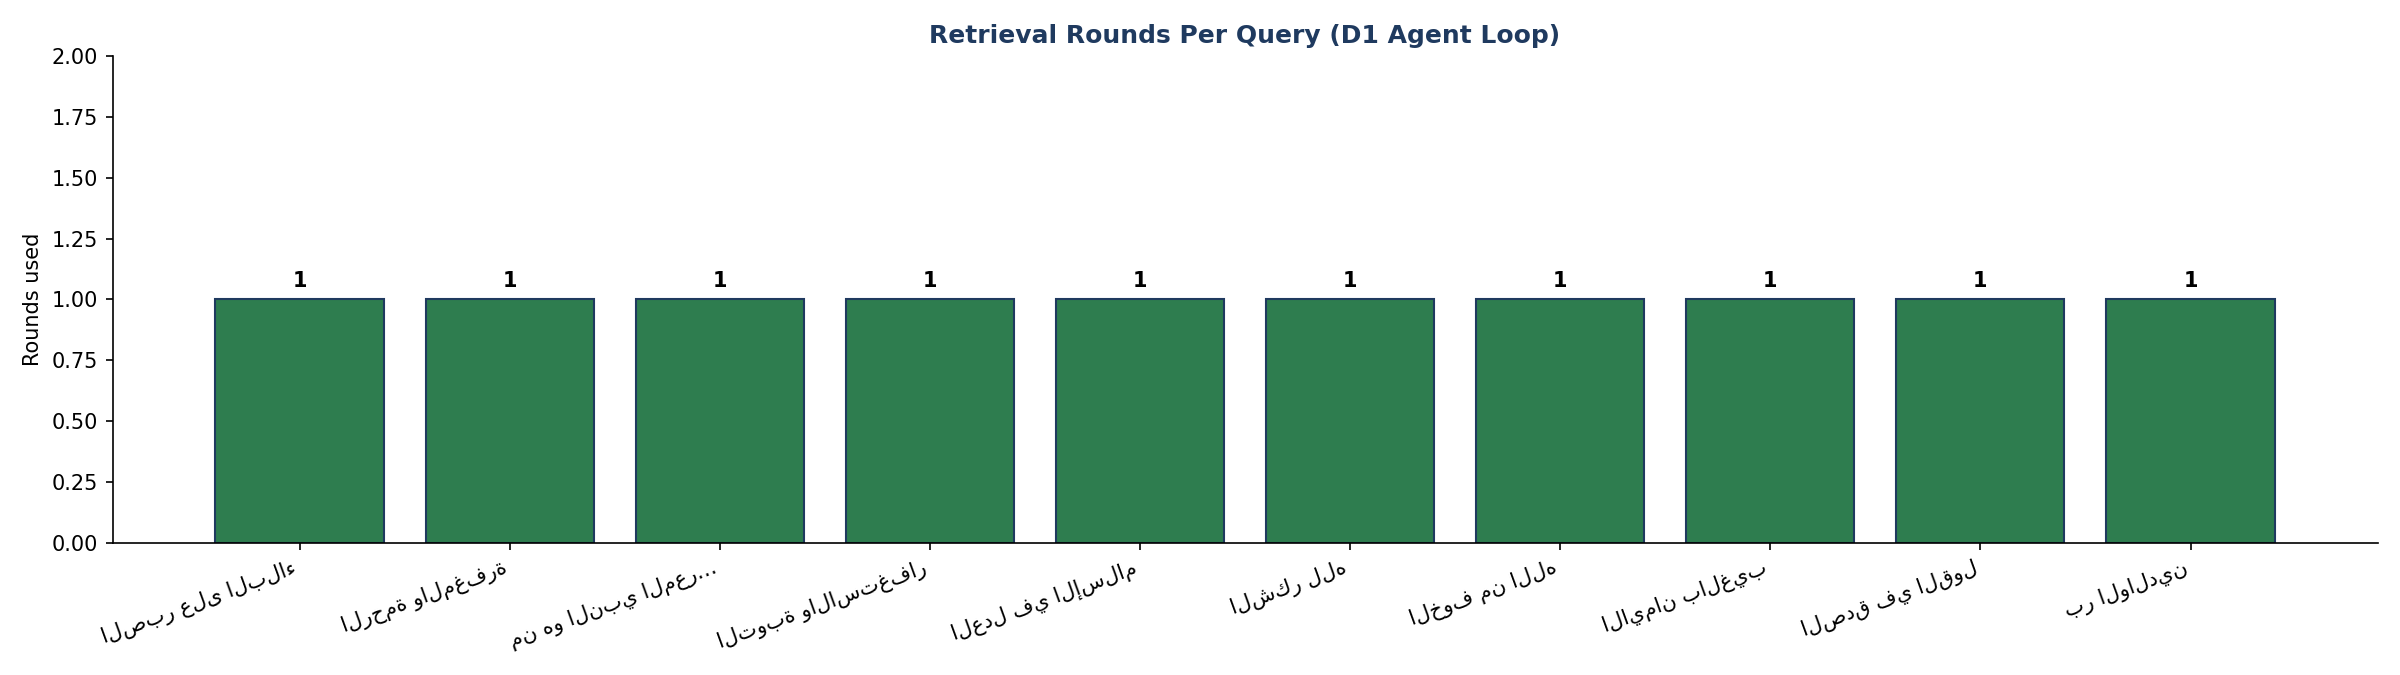


02_fallback_triggers.png


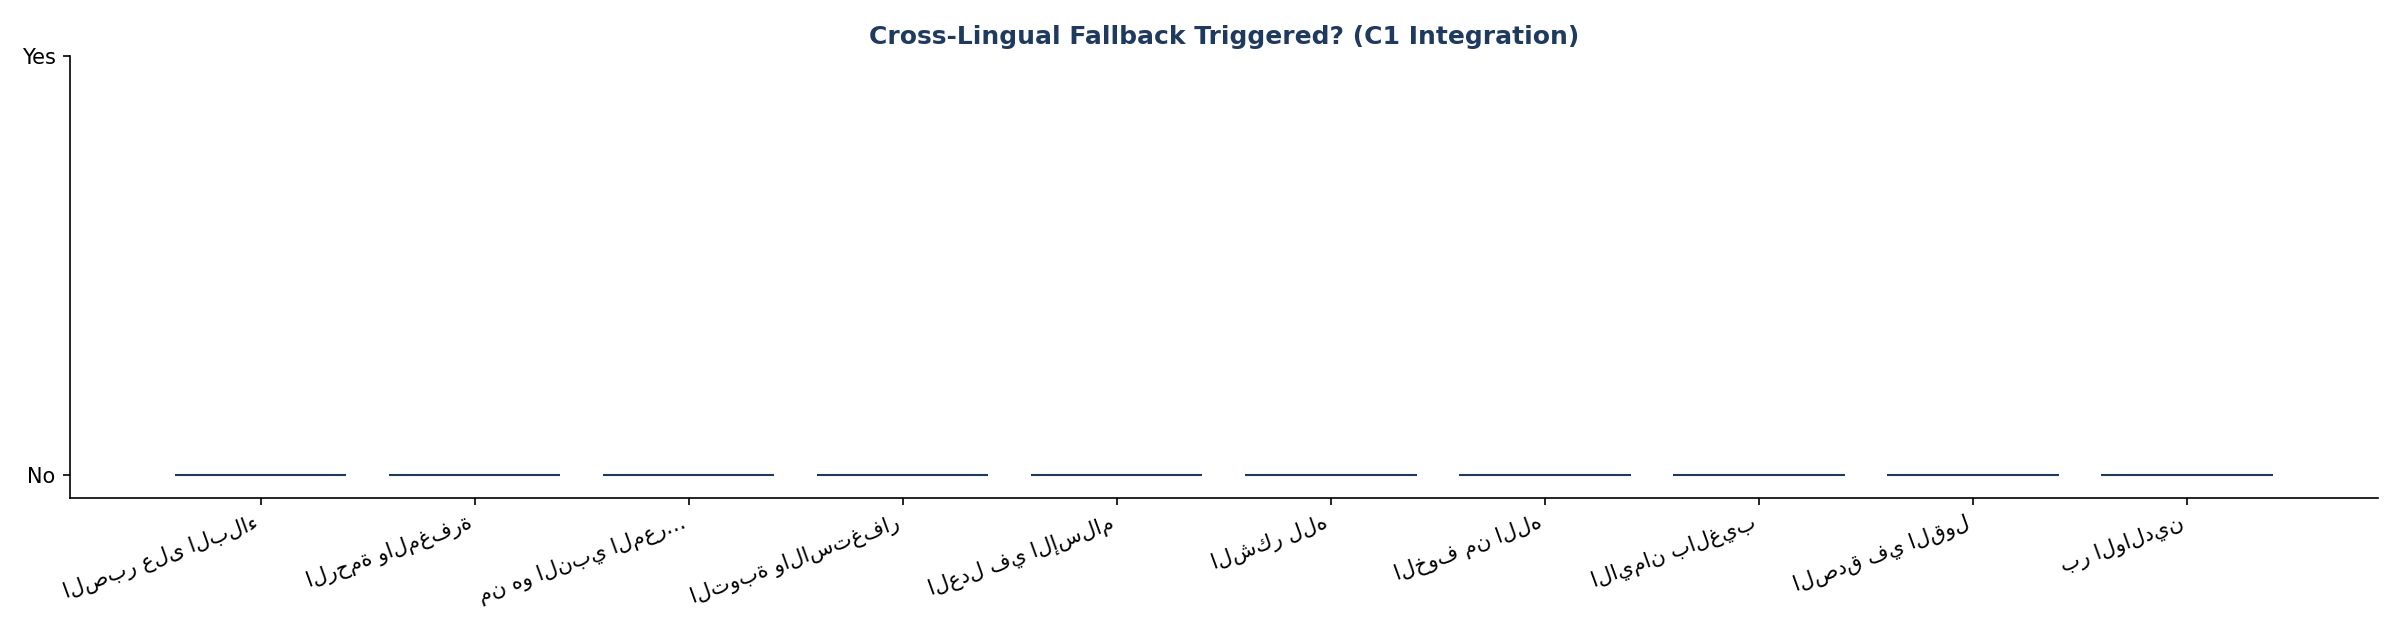


03_grounding_results.png


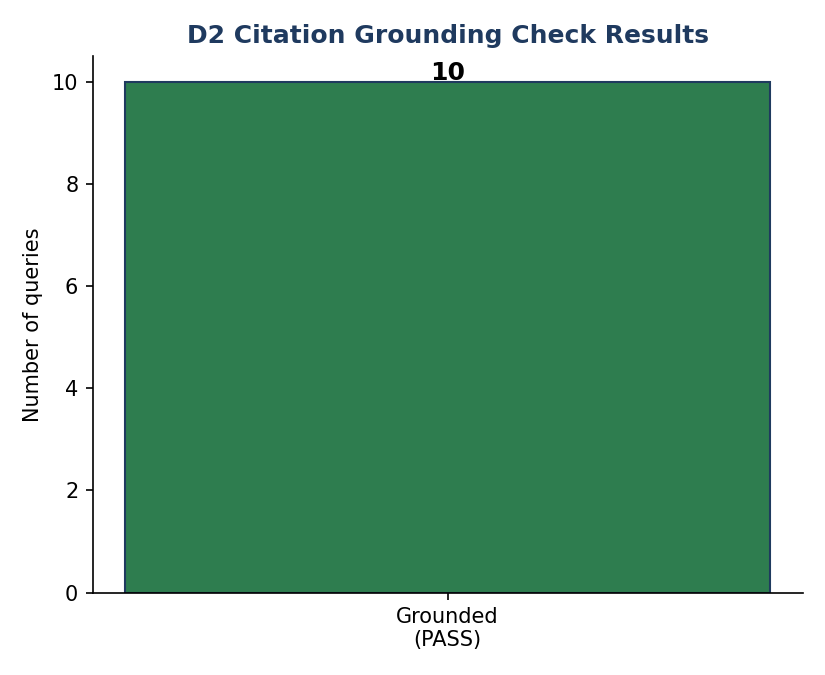


04_summary_table.png


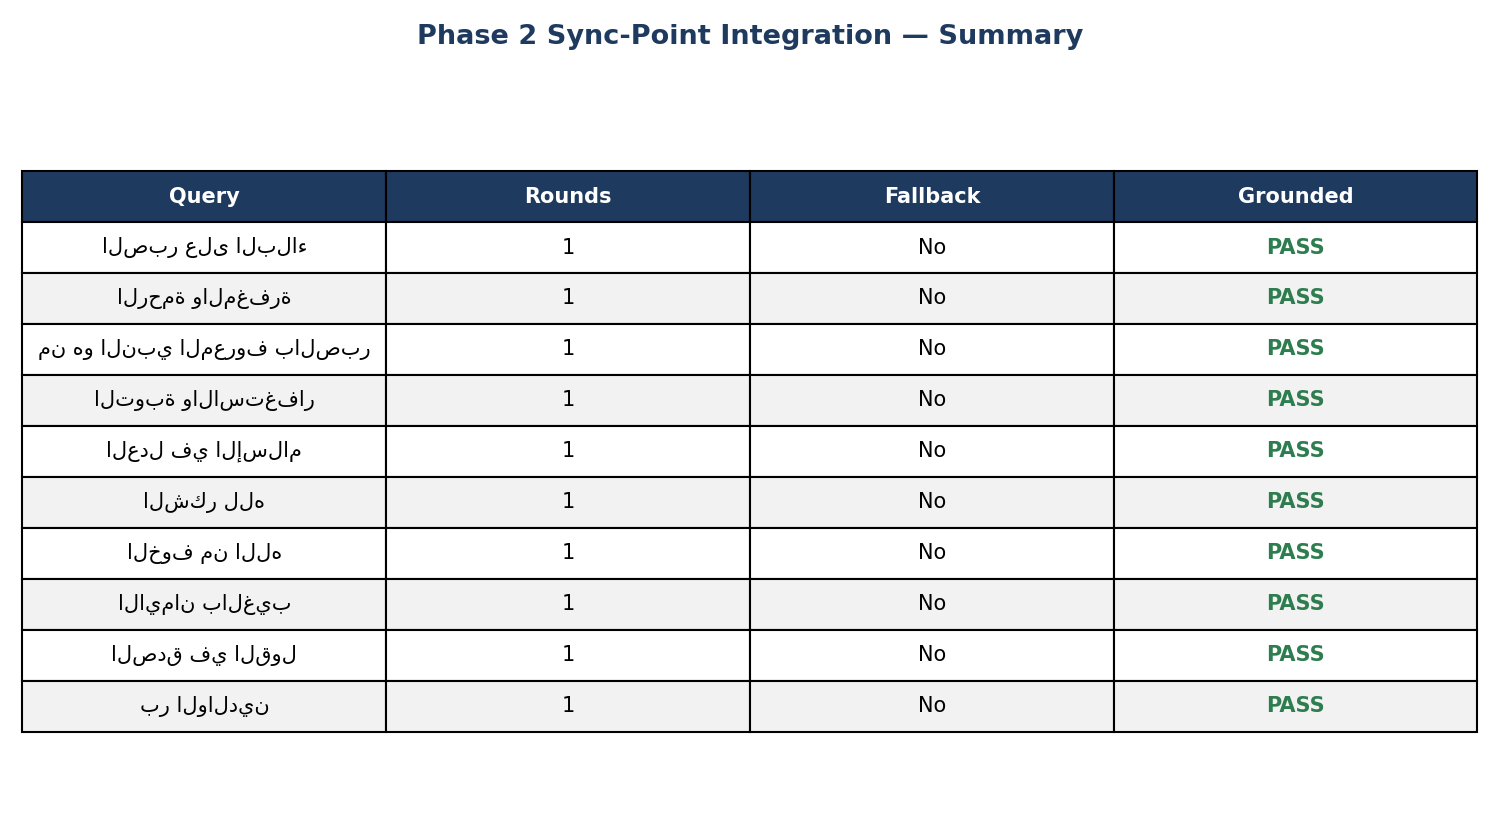

In [ ]:
from IPython.display import Image, display
import os

for fname in sorted(os.listdir("graphs")):
    print(f"\n{fname}")
    display(Image(filename=f"graphs/{fname}"))

## 13. Save results to Drive

In [ ]:
import json

DEST = "/content/drive/MyDrive/Phase2_Project/Laiba_integration_output"
os.makedirs(DEST, exist_ok=True)

with open(f"{DEST}/test_query_results.json", "w", encoding="utf-8") as f:
    json.dump(results, f, ensure_ascii=False, indent=2)

print(f"Saved to: {DEST}/test_query_results.json")
!cat "{DEST}/test_query_results.json"


Saved to: /content/drive/MyDrive/Phase2_Project/Laiba_integration_output/test_query_results.json
[
  {
    "query": "الصبر على البلاء",
    "final_query": "الصبر على البلاء",
    "stopped_reason": "sufficient",
    "rounds": 1,
    "used_fallback": false,
    "sufficiency_score": 0.7720175385475159,
    "similarities": [
      0.7720175385475159,
      0.7635788917541504,
      0.7629605531692505,
      0.7557909488677979,
      0.7543473243713379
    ],
    "cited_verse_keys": [
      "53:38",
      "74:47",
      "89:27"
    ],
    "grounding_ok": true,
    "answer": "The provided context does not fully address the concept of الصبر على البلاء (patience in the face of tribulation) directly. While verses like [53:38], [74:47], and [89:27] touch upon related concepts such as personal responsibility, endurance, and the state of the soul, they do not explicitly provide guidance on patience in tribulation [53:38, 74:47, 89:27]."
  },
  {
    "query": "الرحمة والمغفرة",
    "final_query": "

In [ ]:
DEST = "/content/drive/MyDrive/Phase2_Project/Laiba_integration_output"
os.makedirs(DEST, exist_ok=True)

!cp -r graphs "{DEST}/"
print(f"Saved to: {DEST}/graphs")
!ls "{DEST}/graphs"

Saved to: /content/drive/MyDrive/Phase2_Project/Laiba_integration_output/graphs
01_rounds_per_query.png   03_grounding_results.png
02_fallback_triggers.png  04_summary_table.png


In [ ]:
from google.colab import files
uploaded = files.upload()  # select generate_phase2_dashboard.py

!pip install -q numpy matplotlib
!python generate_phase2_dashboard.py

Saving generate_phase2_dashboard.py to generate_phase2_dashboard.py
[OK] Loaded 10 real test query results.
[SAVED] graphs/phase2_dashboard.png

[RESULT] Dashboard generated.


In [ ]:
!cp graphs/phase2_dashboard.png "/content/drive/MyDrive/Phase2_Project/Laiba_integration_output/"

## Where this leaves Phase 2

If the queries above ran cleanly - correct retries on weak retrieval, correct fallback triggering on the ambiguous query, and grounded CoT answers citing real verse keys - both tracks (Roma's C1-C3 and your D1-D3) are confirmed working together. This is the joint end-to-end test called for in the Phase 2 Implementation Plan.